In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import os
letters = 'abcdefghijklmnopqrstuvwxyz'

In [2]:
# plt.rcParams['font.size']      = 18
plt.rcParams['font.weight']       = 'bold'
plt.rcParams['axes.labelweight']  = 'bold'
plt.rcParams['axes.titleweight']  = 'bold'
plt.rcParams['axes.grid']      = True
plt.rcParams['axes.xmargin']   = 0
plt.rcParams['grid.linestyle'] = ':'

In [3]:
def annotate_duration(ax,xx_0,xx_1,label='T_B',color='red'):
    T_B  = xx_1 - xx_0
    ax.axvline(xx_0, color=color, linestyle='--', linewidth=1)
    ax.axvline(xx_1, color=color, linestyle='--', linewidth=1)

    yy_0 = 0.80
    ax.annotate(
    '',  # No text
    xy=(xx_1, yy_0),    # End of arrow (x, y)
    xytext=(xx_0, yy_0),# Start of arrow (x, y)
    arrowprops=dict(
        arrowstyle='<->',
        color=color,
        linewidth=2),
    annotation_clip=False)

    ax.text(
    (xx_0 + xx_1) / 2, yy_0+0.1,  # Position above the arrow
    f'${label} = {T_B*1e3:.1f}$ ms',
    ha='center', va='bottom', color=color, fontsize=12)

/var/folders/bz/ym0kqkts57sd2tqtpp__3y29gzth2_/T/ipykernel_91553/2581733840.py:66: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


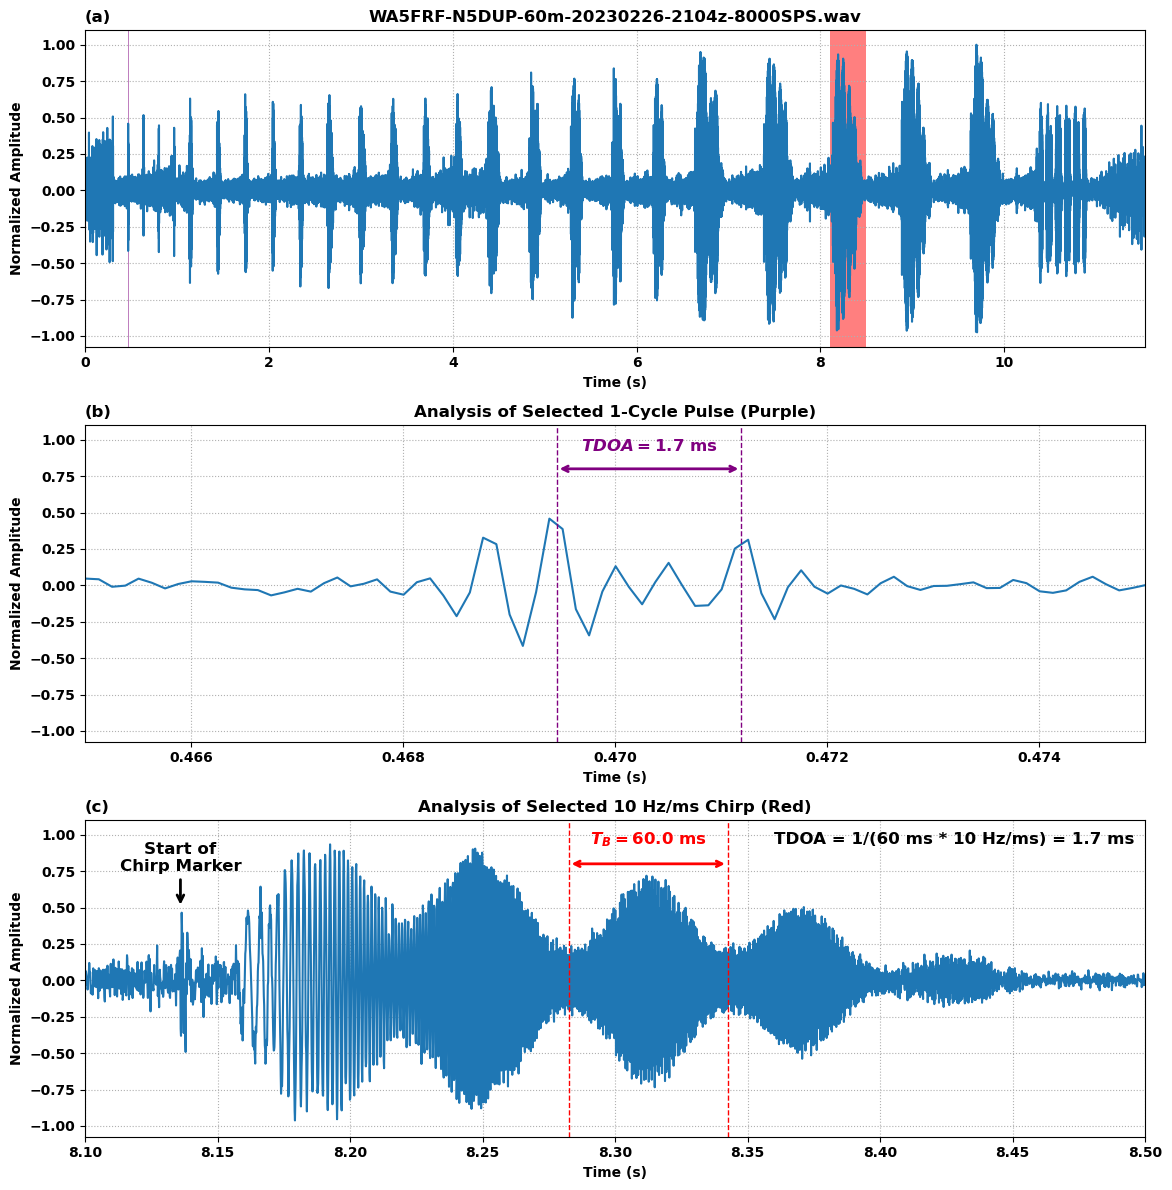

In [4]:
def fig_05(fname = 'WA5FRF-N5DUP-60m-20230226-2104z-8000SPS.wav',
           cycle_xlim = (0.4650, 0.4750), cycle_loc  = (0.46945, 0.47119),
           chirp_xlim = (8.1, 8.5), chirp_loc  = (8.2825, 8.3425)):
    
    file_path = os.path.join('wav',fname)

    sample_rate, data = wavfile.read(file_path)
    data = data / np.max(np.abs(data))  # Normalize the data to -1 to 1

    duration = len(data) / sample_rate
    time = np.linspace(0, duration, num=len(data))

    nrows = 3
    fig = plt.figure(figsize=(12, 4*nrows))
    pinx = 0

    ########################################
    pinx += 1
    ax = fig.add_subplot(nrows, 1, pinx)
    ax.plot(time, data)
    ax.set_title(f'({letters[pinx-1]})',loc='left')
    ax.set_title(fname)
    ax.set_ylabel("Normalized Amplitude")
    ax.axvspan(cycle_xlim[0], cycle_xlim[1], facecolor='purple', alpha=0.5, label='Selected Single Cycle')
    ax.axvspan(chirp_xlim[0], chirp_xlim[1], facecolor='red', alpha=0.5, label='Selected Chirp')
    ax.set_xlabel("Time (s)")

    ########################################
    pinx += 1
    ax = fig.add_subplot(nrows, 1, pinx)
    ax.plot(time, data)
    ax.set_title(f'({letters[pinx-1]})',loc='left')
    ax.set_title('Analysis of Selected 1-Cycle Pulse (Purple)')
    ax.set_ylabel("Normalized Amplitude")
    ax.set_xlim(cycle_xlim)
    ax.set_xlabel("Time (s)")

    annotate_duration(ax,cycle_loc[0],cycle_loc[1],label='TDOA',color='purple')

    ########################################
    pinx += 1
    ax = fig.add_subplot(nrows, 1, pinx)
    ax.plot(time, data)
    ax.set_title(f'({letters[pinx-1]})',loc='left')
    ax.set_title('Analysis of Selected 10 Hz/ms Chirp (Red)')
    ax.set_ylabel("Normalized Amplitude")
    ax.set_xlim(chirp_xlim)
    ax.set_xlabel("Time (s)")

    xmark = 8.136
    ax.annotate(
    'Start of\nChirp Marker',
    xy=(xmark, 0.5),           # Point to annotate (x, y in data coordinates)
    xytext=(xmark, 0.75),     # Position of the text
    arrowprops=dict(facecolor='black', arrowstyle='->',linewidth=2),
    fontsize=12,
    color='black',
    ha='center')

    annotate_duration(ax,chirp_loc[0],chirp_loc[1])

    txt = 'TDOA = 1/(60 ms * 10 Hz/ms) = 1.7 ms'
    ax.text(0.65,0.925,txt,transform=ax.transAxes,fontsize=12)

    fig.tight_layout()
    fig.show()
    fig.savefig('fig_05.jpg',dpi=300,bbox_inches='tight')


# 1st 1-Cycle Pulse
cycle_xlim = (0.46500, 0.47500)
cycle_loc  = (0.46945, 0.47119)

# # 2nd 1-Cycle Pulse
# cycle_xlim = (0.63400, 0.63900)
# cycle_loc  = (0.63610, 0.63790)

fig_05(cycle_xlim=cycle_xlim,cycle_loc=cycle_loc)

**Caption:** (a) TDOA waveform received over a 317 km path at 5.3 MHz near Austin, TX at 2104 UTC on 26 February 2023. Red box corresponds to expanded data shown in (b). (b) Expanded view of a 10 Hz/ms chirp shows a beat note period of 60 ms, which  corresponds to a 1.7 ms TDOA. Using the formulation for 1 and 2 hop multipath from the F2 region, the virtual height model calculates a reflection height of 277 km.